# Renewal Temporal Point Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/renewal_from_scratch_and_numpyro.ipynb)

A **renewal process** has i.i.d. inter-event gaps $\Delta t_i \sim F$ on $[0, T]$. With density $f$ and survival $S = 1 - F$, the joint log-likelihood of events $\{t_1, \dots, t_n\}$ is

$$\log L = \sum_{i=1}^n \log f(\Delta t_i) + \log S(T - t_n).$$

When $F = \mathrm{Exp}(\lambda)$ this collapses to an HPP. Picking $\mathrm{Gamma}(k, \lambda)$ with $k > 1$ gives **regular** (sub-Poisson) sequences; $k < 1$ gives **bursty** ones. This notebook walks through both sides of the API:

1. **From scratch** — direct use of the primitives `renewal_log_prob`, `renewal_sample`.
2. **With NumPyro** — the `RenewalProcess` distribution wrapper + NUTS inference for the inter-event parameters.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes.distributions import RenewalProcess as RenewalDist
from xtremax.point_processes.primitives import (
    renewal_hazard,
    renewal_log_prob,
    renewal_sample,
)


numpyro.set_host_device_count(1)
key = random.PRNGKey(0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From Scratch: Primitives

Three inter-event laws with the same mean = 1 so we can compare shapes directly.

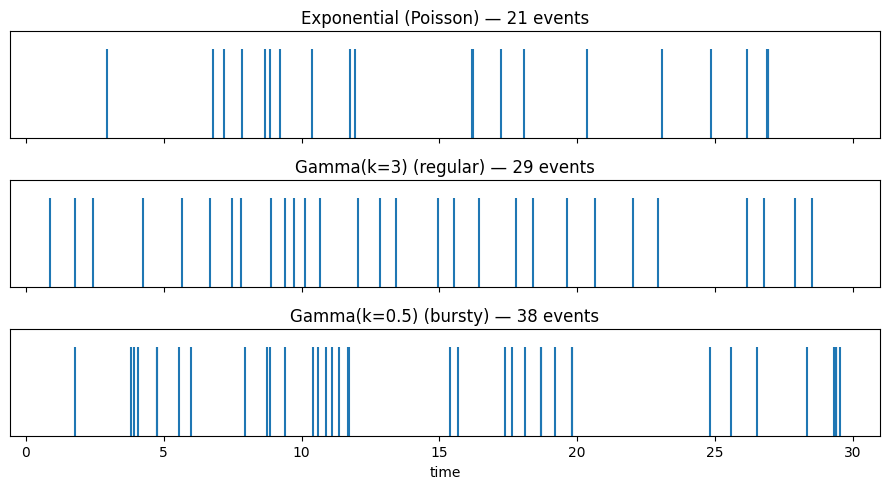

In [2]:
laws = {
    "Exponential (Poisson)": dist.Exponential(rate=1.0),
    "Gamma(k=3) (regular)": dist.Gamma(concentration=3.0, rate=3.0),
    "Gamma(k=0.5) (bursty)": dist.Gamma(concentration=0.5, rate=0.5),
}

T = 30.0

fig, axes = plt.subplots(len(laws), 1, figsize=(9, 5), sharex=True)
for ax, (name, d) in zip(axes, laws.items()):
    t, m, n = renewal_sample(key, d, T, max_events=256)
    ev = np.asarray(t[m])
    ax.vlines(ev, 0, 1, color="C0")
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])
    ax.set_title(f"{name} — {int(n)} events")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

Hazard functions show the shape differences: Exponential is flat, regular Gamma is increasing (memory "builds up"), bursty Gamma is decreasing (clustered events).

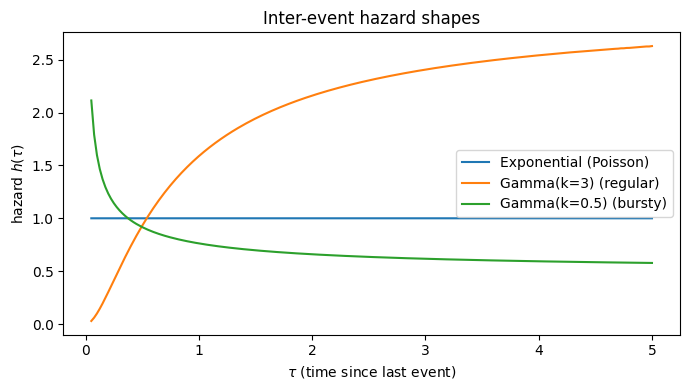

In [3]:
tau = jnp.linspace(0.05, 5.0, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for name, d in laws.items():
    h = renewal_hazard(tau, d)
    ax.plot(tau, h, label=name)
ax.set_xlabel(r"$\tau$ (time since last event)")
ax.set_ylabel(r"hazard $h(\tau)$")
ax.legend()
ax.set_title("Inter-event hazard shapes")
plt.tight_layout()
plt.show()

### Log-likelihood sanity check

For Exponential inter-events the renewal log-prob equals the HPP log-prob exactly — a cross-family invariant we use to smoke-test the primitive.

In [4]:
from xtremax.point_processes.primitives import hpp_log_prob


times = jnp.array([0.3, 1.1, 2.0, 2.8, 3.9])
mask = jnp.array([True] * 5)
T_small = 5.0
rate = 1.3
ll_r = float(renewal_log_prob(times, mask, T_small, dist.Exponential(rate)))
ll_h = float(hpp_log_prob(jnp.sum(mask), rate, T_small))
print(f"renewal = {ll_r:.4f}  hpp = {ll_h:.4f}  diff = {abs(ll_r - ll_h):.2e}")

renewal = -5.1882  hpp = -5.1882  diff = 4.77e-07


## 2. With NumPyro: Inference

Given observations from a Gamma(k=2, λ=1.5) renewal process, recover the posterior over $(k, \lambda)$ with NUTS.

In [5]:
true_k, true_lam = 2.0, 1.5
T_obs = 80.0
obs_dist = RenewalDist(
    dist.Gamma(concentration=true_k, rate=true_lam),
    observation_window=T_obs,
    max_events=512,
)
obs_value = obs_dist.sample(random.PRNGKey(1))
n_obs = int(jnp.sum(obs_value[1]))
print(
    f"observed {n_obs} events on [0, {T_obs}] — expected ~ {true_lam / true_k * T_obs:.1f}"
)


def model(obs):
    k = numpyro.sample("k", dist.LogNormal(0.0, 0.5))
    lam = numpyro.sample("rate", dist.LogNormal(0.0, 0.5))
    d = RenewalDist(
        dist.Gamma(concentration=k, rate=lam),
        observation_window=T_obs,
        max_events=512,
    )
    numpyro.sample("events", d, obs=obs)


mcmc = MCMC(NUTS(model), num_warmup=400, num_samples=400, progress_bar=False)
mcmc.run(random.PRNGKey(2), obs_value)
samples = mcmc.get_samples()
print(
    f"posterior k       = {float(jnp.mean(samples['k'])):.3f} ± "
    f"{float(jnp.std(samples['k'])):.3f}  (truth {true_k})"
)
print(
    f"posterior rate    = {float(jnp.mean(samples['rate'])):.3f} ± "
    f"{float(jnp.std(samples['rate'])):.3f}  (truth {true_lam})"
)

observed 57 events on [0, 80.0] — expected ~ 60.0


posterior k       = 1.930 ± 0.292  (truth 2.0)
posterior rate    = 1.353 ± 0.245  (truth 1.5)


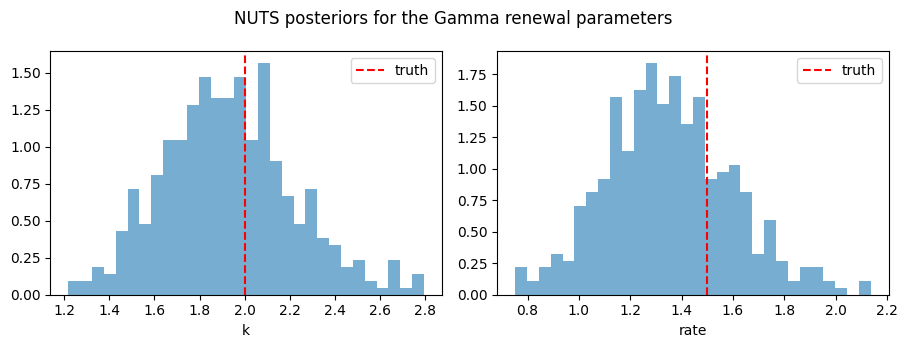

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (name, truth) in zip(axes, [("k", true_k), ("rate", true_lam)]):
    ax.hist(np.asarray(samples[name]), bins=30, density=True, alpha=0.6)
    ax.axvline(truth, color="red", linestyle="--", label="truth")
    ax.set_xlabel(name)
    ax.legend()
plt.suptitle("NUTS posteriors for the Gamma renewal parameters")
plt.tight_layout()
plt.show()

Both parameters are well identified from ~120 events; the regular-Gamma shape $k=2$ is recovered despite the prior being centred at 1.